# 2D FWI

这个示例使用二阶 FDTD，并对介电常数和电导率采用分阶段反演。梯度在送入 Adam 前只做方向保持的尺度预处理，避免物理量级较大时 float32 范数和 Adam 二阶矩溢出。

device: cpu fdtd_order: 2 model shape: (220, 120)


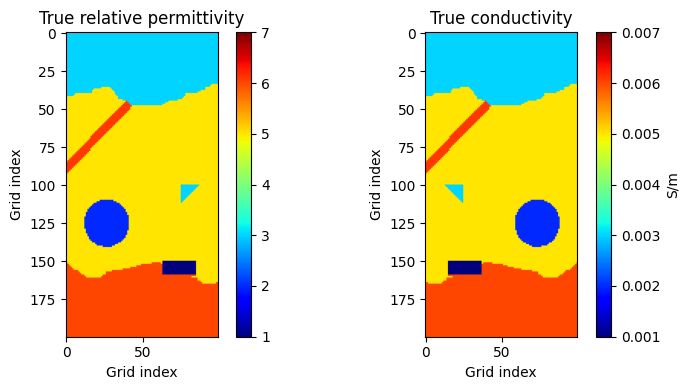

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from skimage import filters

# 只允许加载当前 DeepGPR 项目中的源码，不使用 site-packages 里的旧版本。
cwd = Path.cwd().resolve()
candidate_roots = (cwd, cwd.parent, cwd / "DeepGPR")
project_root = next(
    (path for path in candidate_roots if (path / "src" / "DeepGPR" / "__init__.py").is_file()),
    None,
)
if project_root is None:
    raise RuntimeError(
        "Cannot locate this DeepGPR repository. Start Jupyter from the project root or examples folder."
    )
src_path = (project_root / "src").resolve()
if str(src_path) in sys.path:
    sys.path.remove(str(src_path))
sys.path.insert(0, str(src_path))

import DeepGPR

loaded_package = Path(DeepGPR.__file__).resolve()
if not loaded_package.is_relative_to(src_path):
    raise RuntimeError(
        f"DeepGPR was already imported from {loaded_package}. "
        "Restart the kernel so the project-local package can be loaded."
    )
print("DeepGPR project package:", loaded_package)

if torch.cuda.is_available():
    device = torch.device("cuda:1" if torch.cuda.device_count() > 1 else "cuda:0")
else:
    device = torch.device("cpu")

FDTD_ORDER = 2
PML_WIDTH = 10
dx = 0.05
dt = 5.0e-11
nt = 2000
frequency = 2.0e8

source_location = torch.zeros((50, 1, 3), device=device, dtype=torch.int32)
source_location[:, 0, 0] = torch.arange(10, 210, 4, device=device)
source_location[:, :, 1] = 10

receiver_location = torch.zeros((50, 200, 3), device=device, dtype=torch.int32)
receiver_location[:, :, 0] = torch.arange(10, 210, device=device).repeat(50, 1)
receiver_location[:, :, 1] = 110

source_amplitudes = torch.zeros((1, nt, 1), device=device)
source_amplitudes[0, :, 0] = DeepGPR.ricker(
    frequency, nt, dt, 1.0 / frequency
).to(device)

model_path = Path.cwd() / "2DFWImodel.npy"
if not model_path.exists():
    model_path = project_root / "examples" / "2DFWImodel.npy"
model = torch.as_tensor(np.load(model_path), dtype=torch.float32, device=device)
er_true = F.pad(model[None, None], (10, 10, 10, 10), mode="replicate")[0, 0]
se_true = er_true.clone() * 1.0e-3
se_true[105:, :] = torch.flip(se_true[105:, :], dims=[1])

assert torch.isfinite(er_true).all() and torch.isfinite(se_true).all()
print("device:", device, "fdtd_order:", FDTD_ORDER, "model shape:", tuple(er_true.shape))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
im1 = axes[0].imshow(er_true[10:-10, 10:-10].cpu(), cmap="jet", vmin=1, vmax=7)
plt.colorbar(im1, ax=axes[0])
axes[0].set_title("True relative permittivity")
axes[0].set_xlabel("Grid index")
axes[0].set_ylabel("Grid index")
im2 = axes[1].imshow(se_true[10:-10, 10:-10].cpu(), cmap="jet", vmin=0.001, vmax=0.007)
plt.colorbar(im2, ax=axes[1], label="S/m")
axes[1].set_title("True conductivity")
axes[1].set_xlabel("Grid index")
axes[1].set_ylabel("Grid index")
plt.tight_layout()
plt.show()

observed max amplitude: 11.425061225891113


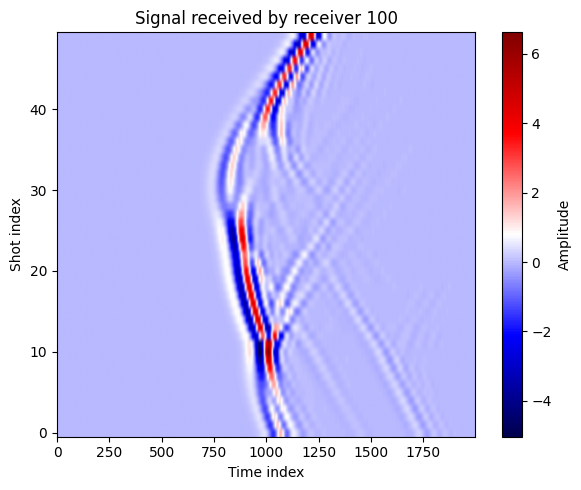

In [2]:
# 生成观测数据。正演不需要保存反传波场。
with torch.no_grad():
    r_obs = DeepGPR.compute(
        device=device,
        dx=dx,
        dt=dt,
        source_amplitudes=source_amplitudes,
        source_location=source_location,
        receiver_location=receiver_location,
        er=er_true,
        se=se_true,
        pmlthick=PML_WIDTH,
        fdtd_order=FDTD_ORDER,
    )[-1].detach()

assert torch.isfinite(r_obs).all(), "Observed data contain NaN or Inf."
data_scale = r_obs.abs().amax().clamp_min(torch.finfo(r_obs.dtype).tiny)
print("observed max amplitude:", float(data_scale))

plt.figure(figsize=(6, 5))
im = plt.imshow(r_obs[:, :, 100].cpu(), cmap="seismic", origin="lower", aspect="auto")
plt.colorbar(im, label="Amplitude")
plt.title("Signal received by receiver 100")
plt.xlabel("Time index")
plt.ylabel("Shot index")
plt.tight_layout()
plt.show()

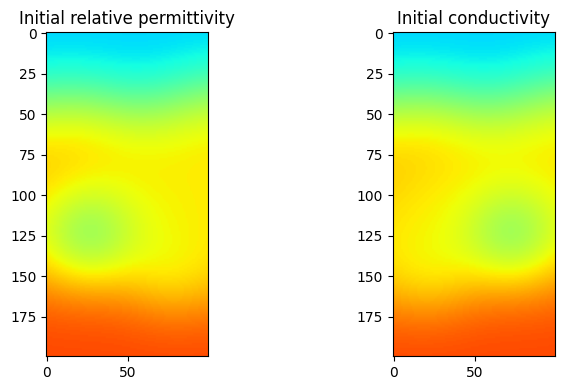

In [3]:
# skimage 在 CPU 上平滑，再将结果送回目标设备，兼容服务器 CUDA 环境。
er_initial = filters.gaussian(
    er_true.detach().cpu().numpy(), sigma=20, preserve_range=True
)
se_initial = filters.gaussian(
    se_true.detach().cpu().numpy(), sigma=20, preserve_range=True
)
er = torch.as_tensor(er_initial, dtype=torch.float32, device=device).clone().requires_grad_(True)
se = torch.as_tensor(se_initial, dtype=torch.float32, device=device).clone().requires_grad_(True)

phase1_epochs = 50
n_epochs = 201
tv_ratio = 0.1

optimizer_phase1 = torch.optim.Adam([er], lr=0.1, eps=1.0e-6)
optimizer_phase2 = torch.optim.Adam(
    [{"params": [er], "lr": 0.05}, {"params": [se], "lr": 5.0e-5}],
    eps=1.0e-6,
)
tv_criterion = DeepGPR.TVRegularization(weight_ep=1.0, weight_sigma=1.0).to(device)

# CPML 内的材料保持初始值，只反演物理区域。
update_mask = torch.zeros_like(er, dtype=torch.bool)
update_mask[PML_WIDTH:-PML_WIDTH, PML_WIDTH:-PML_WIDTH] = True
er_fixed = er.detach().clone()
se_fixed = se.detach().clone()

def rms_unit_gradient(gradient, name):
    """保持梯度方向，将 RMS 稳定缩放为 1，避免 float32 范数溢出。"""
    if gradient is None:
        raise RuntimeError(f"{name} gradient is None.")
    gradient = torch.where(update_mask, gradient, 0.0)
    if not torch.isfinite(gradient).all():
        raise RuntimeError(f"{name} gradient contains NaN or Inf before optimizer.step().")
    max_abs = gradient.abs().amax()
    if max_abs.item() == 0.0:
        return torch.zeros_like(gradient), 0.0
    scaled = gradient / max_abs
    rms = scaled.square().mean().sqrt().clamp_min(torch.finfo(scaled.dtype).eps)
    return scaled / rms, float(max_abs)

def check_model_finite(epoch):
    if not torch.isfinite(er).all() or not torch.isfinite(se).all():
        raise RuntimeError(f"Model became non-finite after epoch {epoch}.")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(er[10:-10, 10:-10].detach().cpu(), cmap="jet", vmin=1, vmax=7)
axes[0].set_title("Initial relative permittivity")
axes[1].imshow(se[10:-10, 10:-10].detach().cpu(), cmap="jet", vmin=0.001, vmax=0.007)
axes[1].set_title("Initial conductivity")
plt.tight_layout()
plt.show()

Epoch 000 | data=1.046824e-02 | tv=5.294861e+02 | raw_grad_max(er)=4.841e-06 | raw_grad_max(se)=0.000e+00 | epoch=59.28s | total=59.28s


/var/folders/nm/2n89zz0x53gbk9546w6x328m0000gn/T/ipykernel_76168/951276238.py:56: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  history.append({"epoch": epoch, "data_loss": float(loss_data), "tv_loss": float(loss_tv)})


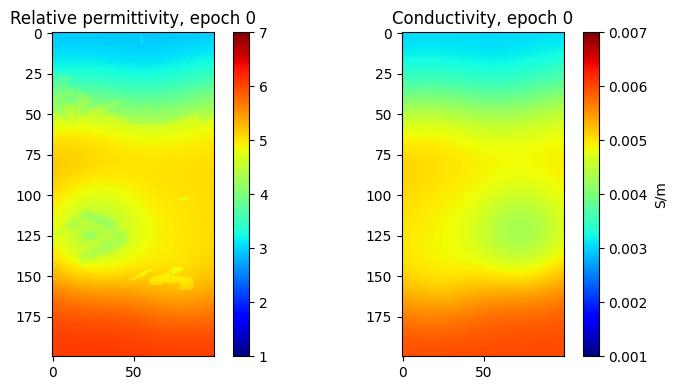

Epoch 001 | data=8.325523e-03 | tv=7.807914e+02 | raw_grad_max(er)=3.526e-06 | raw_grad_max(se)=0.000e+00 | epoch=75.27s | total=134.72s
Epoch 002 | data=7.344045e-03 | tv=9.603060e+02 | raw_grad_max(er)=4.213e-06 | raw_grad_max(se)=0.000e+00 | epoch=73.40s | total=208.12s
Epoch 003 | data=6.964501e-03 | tv=1.139816e+03 | raw_grad_max(er)=4.686e-06 | raw_grad_max(se)=0.000e+00 | epoch=73.18s | total=281.30s
Epoch 004 | data=6.445952e-03 | tv=1.293399e+03 | raw_grad_max(er)=4.042e-06 | raw_grad_max(se)=0.000e+00 | epoch=72.43s | total=353.72s
Epoch 005 | data=5.838056e-03 | tv=1.437667e+03 | raw_grad_max(er)=3.944e-06 | raw_grad_max(se)=0.000e+00 | epoch=72.84s | total=426.56s
Epoch 006 | data=5.416131e-03 | tv=1.581045e+03 | raw_grad_max(er)=3.432e-06 | raw_grad_max(se)=0.000e+00 | epoch=75.09s | total=501.65s
Epoch 007 | data=5.194806e-03 | tv=1.722469e+03 | raw_grad_max(er)=3.588e-06 | raw_grad_max(se)=0.000e+00 | epoch=77.33s | total=578.98s
Epoch 008 | data=4.886864e-03 | tv=1.8581

In [ ]:
history = []
start_time = time.time()

for epoch in range(n_epochs):
    phase1 = epoch < phase1_epochs
    current_optimizer = optimizer_phase1 if phase1 else optimizer_phase2
    er.requires_grad_(True)
    se.requires_grad_(not phase1)
    current_optimizer.zero_grad(set_to_none=True)
    epoch_start = time.time()

    r = DeepGPR.compute(
        device=device,
        dx=dx,
        dt=dt,
        source_amplitudes=source_amplitudes,
        source_location=source_location,
        receiver_location=receiver_location,
        er=er,
        se=se,
        pmlthick=PML_WIDTH,
        model_gradient_sampling_interval=5,
        fdtd_order=FDTD_ORDER,
    )[-1]

    # 用无量纲残差代替旧代码中的 1e7 人工放大。
    residual = (r - r_obs) / data_scale
    loss_data = F.smooth_l1_loss(residual, torch.zeros_like(residual), beta=0.05)
    loss_data.backward()
    grad_data_er, raw_max_er = rms_unit_gradient(er.grad.detach(), "data/er")
    if se.requires_grad:
        grad_data_se, raw_max_se = rms_unit_gradient(se.grad.detach(), "data/se")
    else:
        grad_data_se, raw_max_se = None, 0.0

    current_optimizer.zero_grad(set_to_none=True)
    loss_tv = tv_criterion(er, se if se.requires_grad else None)
    loss_tv.backward()
    grad_tv_er, _ = rms_unit_gradient(er.grad.detach(), "tv/er")
    er.grad = grad_data_er + tv_ratio * grad_tv_er
    if se.requires_grad:
        grad_tv_se, _ = rms_unit_gradient(se.grad.detach(), "tv/se")
        se.grad = grad_data_se + tv_ratio * grad_tv_se

    if not torch.isfinite(er.grad).all() or (se.requires_grad and not torch.isfinite(se.grad).all()):
        raise RuntimeError(f"Combined gradient became non-finite at epoch {epoch}.")
    current_optimizer.step()

    with torch.no_grad():
        er.clamp_(1.0, 12.0)
        se.clamp_(0.0, 0.02)
        er[~update_mask] = er_fixed[~update_mask]
        se[~update_mask] = se_fixed[~update_mask]
    check_model_finite(epoch)

    history.append({"epoch": epoch, "data_loss": float(loss_data), "tv_loss": float(loss_tv)})
    epoch_time = time.time() - epoch_start
    total_time = time.time() - start_time
    print(
        f"Epoch {epoch:03d} | data={float(loss_data):.6e} | tv={float(loss_tv):.6e} "
        f"| raw_grad_max(er)={raw_max_er:.3e} | raw_grad_max(se)={raw_max_se:.3e} "
        f"| epoch={epoch_time:.2f}s | total={total_time:.2f}s"
    )

    if epoch % 50 == 0 or epoch == n_epochs - 1:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        im1 = axes[0].imshow(er[10:-10, 10:-10].detach().cpu(), cmap="jet", vmin=1, vmax=7)
        plt.colorbar(im1, ax=axes[0])
        axes[0].set_title(f"Relative permittivity, epoch {epoch}")
        im2 = axes[1].imshow(se[10:-10, 10:-10].detach().cpu(), cmap="jet", vmin=0.001, vmax=0.007)
        plt.colorbar(im2, ax=axes[1], label="S/m")
        axes[1].set_title(f"Conductivity, epoch {epoch}")
        plt.tight_layout()
        plt.show()